In [1]:
import numpy as np
import pandas as pd

import torch
import torch.nn as nn

import matplotlib.pyplot as plt
from sklearn.metrics import classification_report

(This script uses a tiny test dataset but is scaled up on the full set for our actual project) 

In [2]:
# load data
x_train = torch.load("data/test_embeddings/x_train")
x_val = torch.load("data/test_embeddings/x_val")
x_test = torch.load("data/test_embeddings/x_test")
y_train = torch.load("data/test_embeddings/y_train")
y_val = torch.load("data/test_embeddings/y_val")
y_test = torch.load("data/test_embeddings/y_test")

In [3]:
class Feedforward(torch.nn.Module):
    """
    Basic feedforward MLP for binary classification of BERT-embedding sentences
    """
    def __init__(self, input_size, hidden_size):
        super(Feedforward, self).__init__()
        self.input_size = input_size
        self.hidden_size  = hidden_size
        self.fc1 = nn.Linear(self.input_size, self.hidden_size)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(self.hidden_size, 1)
        self.sigmoid = nn.Sigmoid()
      
    def forward(self, x):
        hidden = self.fc1(x)
        relu = self.relu(hidden)
        output = self.fc2(relu)
        output = self.sigmoid(output)
        return output

In [4]:
model = Feedforward(768, 10)
criterion = torch.nn.BCELoss()
optimizer = torch.optim.Adam(model.parameters(), lr = 0.0001) 
n_epochs = 10

In [5]:
train_losses = []
val_losses = []

for epoch in range(n_epochs):
    model.train()
    train_loss = 0
    y_pred = model(x_train[:, 0, :])
    optimizer.zero_grad()
    loss = criterion(y_pred.squeeze(), y_train.squeeze())
    loss.backward()
    optimizer.step()
    train_loss += loss.item()
    train_losses.append(train_loss)

    model.eval() 
    val_loss = 0
    y_pred_val = model(x_val[:, 0, :])
    loss = criterion(y_pred_val.squeeze(), y_val.squeeze())
    val_loss += loss.item()
    val_losses.append(val_loss)
    print("Epoch %d Train loss: %.2f. Validation loss: %.2f"
        % (epoch + 1, train_losses[-1], val_losses[-1]))

Epoch 1 Train loss: 0.69. Validation loss: 0.69
Epoch 2 Train loss: 0.69. Validation loss: 0.69
Epoch 3 Train loss: 0.69. Validation loss: 0.69
Epoch 4 Train loss: 0.69. Validation loss: 0.69
Epoch 5 Train loss: 0.69. Validation loss: 0.69
Epoch 6 Train loss: 0.69. Validation loss: 0.69
Epoch 7 Train loss: 0.69. Validation loss: 0.69
Epoch 8 Train loss: 0.69. Validation loss: 0.69
Epoch 9 Train loss: 0.69. Validation loss: 0.69
Epoch 10 Train loss: 0.69. Validation loss: 0.69


Text(0.5, 1.0, 'Losses')

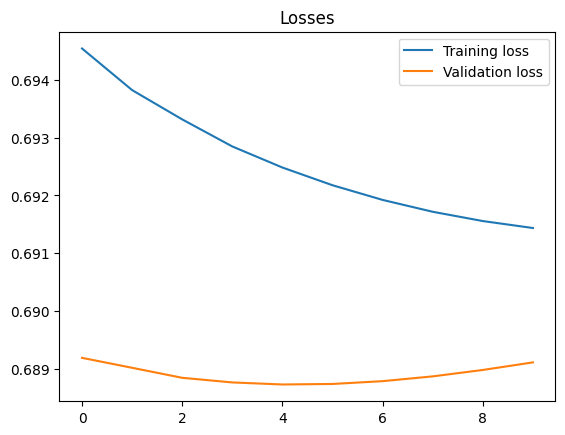

In [6]:
# plot losses
plt.plot(train_losses, label="Training loss")
plt.plot(val_losses, label="Validation loss")
plt.legend()
plt.title("Losses")

In [7]:
# evaluate predictions
test_pred = model(x_test[:, 0, :])
test_binary = np.where(test_pred > 0.5, 1, 0)
print(classification_report(test_binary, y_test.round()))

              precision    recall  f1-score   support

         0.0       1.00      0.50      0.67        10
         1.0       0.00      0.00      0.00         0

    accuracy                           0.50        10
   macro avg       0.50      0.25      0.33        10
weighted avg       1.00      0.50      0.67        10



C:\Users\abhyu\Desktop\Hertie-NLP-Python-Project-master\Hertie-NLP-Python-Project-master\venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\abhyu\Desktop\Hertie-NLP-Python-Project-master\Hertie-NLP-Python-Project-master\venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\abhyu\Desktop\Hertie-NLP-Python-Project-master\Hertie-NLP-Python-Project-master\venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels 